In [13]:
import numpy as np
import matplotlib.pyplot as plt

def exact_sol(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)

def forward_euler(h, t_end):
    t_values = np.arange(0, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = 0  # Initial condition
    
    for i in range(len(t_values) - 1):
        # Forward Euler: y_next = y_curr + h * f(t_curr, y_curr)
        slope = -1000 * y_values[i] + 3000 - 2000 * np.exp(-t_values[i])
        y_values[i+1] = y_values[i] + h * slope
        
        # Safety check for stability: if it blows up to infinity, stop plotting
        if abs(y_values[i+1]) > 1e5:
            return t_values[:i+2], y_values[:i+2]
            
    return t_values, y_values

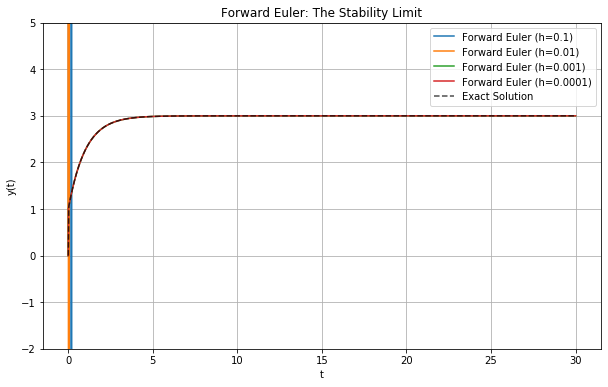

In [19]:
h_list = [0.1, 0.01, 0.001, 0.0001] # Specific values to show the stability limit
t_end = 30

plt.figure(figsize=(10, 6))

for h in h_list:
    t, y = forward_euler(h, t_end)
    plt.plot(t, y, label=f'Forward Euler (h={h})')

t_exact = np.linspace(0, 30, 1000) # Shortened time to see the detail
plt.plot(t_exact, exact_sol(t_exact), 'k--', label='Exact Solution', alpha=0.7)

plt.ylim(-2, 5) # Restrict Y axis because unstable solutions go to infinity
plt.title("Forward Euler: The Stability Limit")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()

Used AI tool, Google Gemini to check code.